# Phase 1
#  Step 1: Load Training Data

In [1]:
import pandas as pd
import os


DATA_DIR = '/kaggle/input/spot-the-difference-challenge/'
TRAIN_CSV_PATH = os.path.join(DATA_DIR, 'train.csv')

# Load the training data
try:
    df_train = pd.read_csv(TRAIN_CSV_PATH)
    print("Training Data Loaded Successfully.")
except FileNotFoundError:
    print(f"Error: train.csv not found at {TRAIN_CSV_PATH}. Check your path.")
    
# Display the first 5 rows to understand the structure
print("\n--- Training Data Head ---")
print(df_train.head())

# Check data shape
print(f"\nTotal training records: {len(df_train)}")

Training Data Loaded Successfully.

--- Training Data Head ---
   img_id  added_objs    removed_objs changed_objs
0   35655        none            none         none
1   30660        none  person vehicle         none
2   34838  man person      car person         none
3   34045      person            none          car
4   30596        none  bicycle person         none

Total training records: 4536


# Step 2: Object Vocabulary and Change Distribution
This step analyzes the raw labels to understand the universe of objects and the frequency of each type of change. This is critical for model training (e.g., handling class imbalance).

# 2.1 Calculate Change Frequency
The labels are stored as space-separated strings. You need to count the occurrences of each object name.

In [2]:
import itertools
from collections import Counter

# Define the columns that contain the object change lists
change_cols = ['added_objs', 'removed_objs', 'changed_objs']

# Function to extract all unique objects and their counts
def analyze_object_labels(df, cols):
    all_objects = []
    
    for col in cols:
        # Replace 'none' with an empty string so it's not counted as an object
        object_lists = df[col].astype(str).str.replace('none', '').str.split(' ')
        # Flatten the list of lists into a single list of all objects
        flat_list = list(itertools.chain.from_iterable(object_lists))
        # Filter out any empty strings that resulted from splitting or replacing 'none'
        all_objects.extend([obj.strip() for obj in flat_list if obj.strip()])
    
    # Count the frequency of each object
    object_counts = Counter(all_objects)
    return object_counts

object_counts = analyze_object_labels(df_train, change_cols)

print("\n--- ALL Objects ---")
print(object_counts)

# Store the unique object names (your class names)
OBJECT_VOCABULARY = sorted(list(object_counts.keys()))
print(f"\nTotal Unique Objects (Classes): {len(OBJECT_VOCABULARY)}")


--- ALL Objects ---
Counter({'person': 3216, 'car': 2146, 'vehicle': 1104, 'man': 301, 'object': 103, 'guy': 51, 'traffic': 32, 'umbrella': 29, 'cart': 27, 'group': 20, 'individual': 20, 'boy': 17, 'pedestrian': 17, 'woman': 16, 'box': 10, 'item': 8, 'bag': 7, 'worker': 6, 'gate': 5, 'dolly': 5, 'motorcycle': 5, 'bicycle': 5, 'child': 5, 'couple': 4, 'kid': 4, 'pole': 4, 'sign': 3, 'dog': 3, 'pickup': 3, 'container': 2, 'luggage': 2, 'girl': 2, 'cone': 2, 'ladder': 1, 'people': 1, 'case': 1, 'lady': 1, 'building': 1, 'bicyclist': 1, 'auto': 1, 'shadow': 1, 'baggage': 1, 'driver': 1, 'chair': 1, 'animal': 1, 'gentleman': 1, 'vest': 1, 'stroller': 1, 'scooter': 1, 'baby': 1, 'personal': 1})

Total Unique Objects (Classes): 51


# 2.2 Analyze "None" (No Change) Distribution
This checks the proportion of images with no changes in each category, which is crucial for the F1 score evaluation (where "none" is a correct prediction).

In [3]:
print("\n--- 'None' (No Change) Distribution ---")

for col in change_cols:
    none_count = (df_train[col] == 'none').sum()
    total_count = len(df_train)
    percentage = (none_count / total_count) * 100
    
    print(f"'{col}': {none_count} out of {total_count} rows ({percentage:.2f}%) have 'none'.")


--- 'None' (No Change) Distribution ---
'added_objs': 1953 out of 4536 rows (43.06%) have 'none'.
'removed_objs': 2609 out of 4536 rows (57.52%) have 'none'.
'changed_objs': 3021 out of 4536 rows (66.60%) have 'none'.


# Step 3: Visual Data Inspection


# 3.1 Load and Display Image Pairs

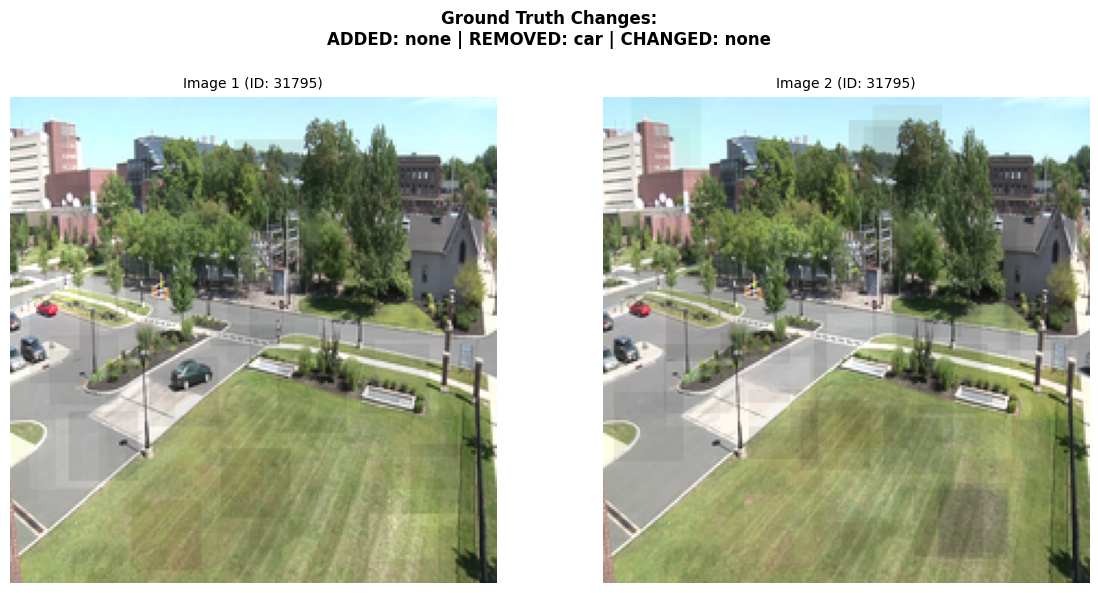

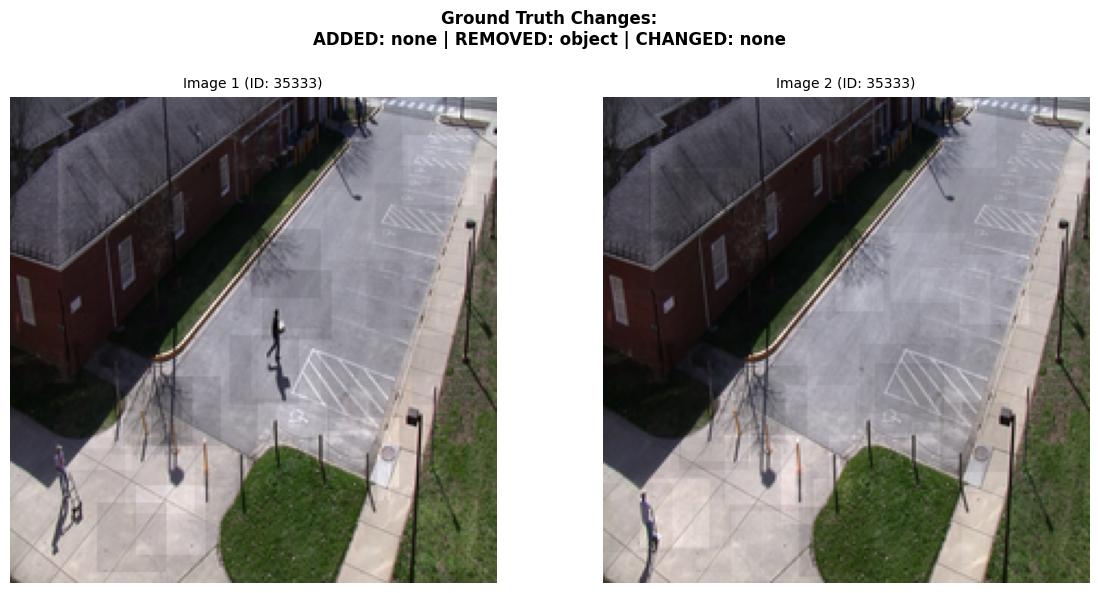

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


IMAGE_FOLDER = os.path.join(DATA_DIR, 'data/data/') 

def display_image_pair(img_id, df, img_folder):
    """Loads and displays an image pair along with its ground truth labels."""
    try:
        
        path1 = os.path.join(img_folder, f"{img_id}_1.png")
        path2 = os.path.join(img_folder, f"{img_id}_2.png")
        
        img1 = Image.open(path1).convert("RGB")
        img2 = Image.open(path2).convert("RGB")

        # Get the ground truth labels
        labels = df[df['img_id'] == img_id].iloc[0]
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(img1)
        axes[0].set_title(f"Image 1 (ID: {img_id})", fontsize=10)
        axes[0].axis('off')
        
        axes[1].imshow(img2)
        axes[1].set_title(f"Image 2 (ID: {img_id})", fontsize=10)
        axes[1].axis('off')
        
        plt.suptitle(
            f"Ground Truth Changes:\n"
            f"ADDED: {labels['added_objs']} | "
            f"REMOVED: {labels['removed_objs']} | "
            f"CHANGED: {labels['changed_objs']}",
            fontsize=12,
            fontweight='bold'
        )
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    except FileNotFoundError:
        print(f"Image files not found for ID {img_id}. Check IMAGE_FOLDER path and naming convention.")
    except IndexError:
        print(f"ID {img_id} not found in DataFrame.")


# Example 1
example_id_mixed = df_train[df_train['removed_objs'] != 'none'].sample(1)['img_id'].iloc[0]
display_image_pair(example_id_mixed, df_train, IMAGE_FOLDER)

# Example 2
example_id_none = df_train[df_train['added_objs'] == 'none'].sample(1)['img_id'].iloc[0]
display_image_pair(example_id_none, df_train, IMAGE_FOLDER)

# Phase 2
# 1. Setup and Data Handling
This block defines parameters, loads the data, and creates the custom Dataset and DataLoader classes required to feed image pairs and multi-label ground truth into the model.

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
import os
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# --- PARAMETERS & CONFIGURATION ---
DATA_DIR = '/kaggle/input/spot-the-difference-challenge/' 
IMAGE_FOLDER = os.path.join(DATA_DIR, 'data/data/')
TRAIN_CSV_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_CSV_PATH = os.path.join(DATA_DIR, 'test.csv')

# Use the top objects found in your previous analysis (51 total classes)
OBJECT_VOCABULARY = ['person', 'car', 'vehicle', 'man', 'object', 'guy', 'traffic', 'umbrella', 'cart', 'group', 'individual', 'boy', 'pedestrian', 'woman', 'box', 'item', 'bag', 'worker', 'gate', 'dolly', 'motorcycle', 'bicycle', 'child', 'couple', 'kid', 'pole', 'sign', 'dog', 'pickup', 'container', 'luggage', 'girl', 'cone', 'ladder', 'people', 'case', 'lady', 'building', 'bicyclist', 'auto', 'shadow', 'baggage', 'driver', 'chair', 'animal', 'gentleman', 'vest', 'stroller', 'scooter', 'baby', 'personal']

OBJECT_MAPPING = {
    'man': 'person', 'boy': 'person', 'woman': 'person', 'girl': 'person',
    'guy': 'person', 'individual': 'person', 'kid': 'person', 'child': 'person',
    'pedestrian': 'person', 'driver': 'person', 'gentleman': 'person', 'lady': 'person',
    'worker': 'person', 'bicyclist': 'bike/scooter', 'people': 'person', 'baby': 'person',
    'auto': 'car', 'pickup': 'car', 'baggage': 'baggage', 'luggage': 'baggage',
    'case': 'baggage', 'container': 'box', 'motorcycle': 'bike/scooter', 
    'bicycle': 'bike/scooter', 'scooter': 'bike/scooter',
    'object': 'none', 'item': 'none', 'personal': 'none' # Ignore these
}

NUM_CLASSES = len(OBJECT_VOCABULARY)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 16
NUM_EPOCHS = 15 
LEARNING_RATE = 1e-4

# Load the training and test data
df_full_train = pd.read_csv(TRAIN_CSV_PATH)
df_train, df_val = train_test_split(df_full_train, test_size=0.2, random_state=42)
df_test = pd.read_csv(TEST_CSV_PATH)


# --- 1.2 Custom Dataset Class ---
class ChangeDetectionDataset(Dataset):
    def __init__(self, df, vocab, image_folder, transform=None):
        self.df = df
        self.vocab = {obj: i for i, obj in enumerate(vocab)}
        self.image_folder = image_folder
        self.transform = transform
        self.change_types = ['added_objs', 'removed_objs', 'changed_objs']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['img_id']

        # Load Images
        img1_path = os.path.join(self.image_folder, f"{img_id}_1.png")
        img2_path = os.path.join(self.image_folder, f"{img_id}_2.png")
        
        try:
            img1 = Image.open(img1_path).convert('RGB')
            img2 = Image.open(img2_path).convert('RGB')
        except FileNotFoundError:
             raise FileNotFoundError(f"Image files not found for ID {img_id}")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        
        # Convert Labels to Multi-Hot Vectors (shape: 3, NUM_CLASSES)
        labels_vector = np.zeros((3, NUM_CLASSES), dtype=np.float32)

        for i, col in enumerate(self.change_types):
            objects_str = str(row[col])
            if objects_str != 'none':
                objects = [obj.strip() for obj in objects_str.split(' ') if obj.strip() in self.vocab]
                
                for obj in objects:
                    # 1. Apply Mapping
                    mapped_obj = OBJECT_MAPPING.get(obj, obj) # Defaults to obj if not in map
        
                    # 2. Check if the mapped object is in the NEW vocabulary AND not 'none'
                    if mapped_obj in self.vocab and mapped_obj != 'none':
                        labels_vector[i, self.vocab[mapped_obj]] = 1.0 # Set the bit

        return img1, img2, torch.tensor(labels_vector), img_id

# --- Data Transformations with Augmentation ---
data_transforms = transforms.Compose([
    # Data Augmentation for robustness against minor color/lighting differences
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.Resize((256, 256)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Dataset and DataLoader
train_dataset = ChangeDetectionDataset(df_train, OBJECT_VOCABULARY, IMAGE_FOLDER, data_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Create Validation DataLoader 
val_dataset = ChangeDetectionDataset(df_val, OBJECT_VOCABULARY, IMAGE_FOLDER, data_transforms)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Model Architecture and Loss
This block defines the Two-Stream CNN model and sets up the loss function and optimizer.

In [6]:
# --- 2.1 Two-Stream CNN Architecture ---
class TwoStreamChangeDetector(nn.Module):
    def __init__(self, num_classes):
        super(TwoStreamChangeDetector, self).__init__()
        
        # 1. Feature Extractor (Shared Weights)
        resnet = resnet50(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*(list(resnet.children())[:-2])) 
        
        # Output features from ResNet-50 backbone (2048 features * 2 streams)
        INPUT_FEATURES = 2048 * 2 

        # 2. Change Classification Head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Global Average Pooling
            nn.Flatten(),
            nn.Linear(INPUT_FEATURES, 1024),
            nn.ReLU(),
            nn.Dropout(0.7),
            # Final output: (3 categories * NUM_CLASSES)
            nn.Linear(1024, 3 * num_classes),
        )

    def forward(self, img1, img2):
        # Extract Features using Shared Backbone
        F1 = self.backbone(img1)
        F2 = self.backbone(img2)
        
        # Concatenate features along the channel dimension for differential learning
        F_concat = torch.cat((F1, F2), dim=1) 
        
        # Classification
        output = self.classifier(F_concat)
        
        # Reshape output to (BatchSize, 3, NUM_CLASSES)
        output = output.view(-1, 3, NUM_CLASSES)
        
        return output

# Initialize Model, Loss, and Optimizer
model = TwoStreamChangeDetector(NUM_CLASSES).to(DEVICE)
criterion = nn.BCEWithLogitsLoss() # Use BCEWithLogitsLoss for multi-label classification
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s]


# 3. Training and Evaluation
This is the main functional loop, including a basic training routine and the critical Mean F1 Score calculation for validation.


In [7]:
# 3.1 Mean F1 Score Metric
def calculate_mean_f1(all_predictions, all_targets):
    """Calculates the Mean F1 Score across the three change categories."""
    f1_scores = []
    
    # Iterate through the three change categories: Added, Removed, Changed
    for i in range(3): 
        targets_category = all_targets[:, i, :] 
        preds_category = all_predictions[:, i, :]

        # Use 'samples' average to calculate F1 per image and then average those F1 scores.
        # This closely matches the competition's per-row F1 calculation logic.
        f1_cat = f1_score(targets_category, preds_category, average='samples', zero_division=1)
        f1_scores.append(f1_cat)

    # Competition Metric: Average the three category F1 scores
    mean_f1 = np.mean(f1_scores)
    
    return mean_f1, f1_scores

# CODE 3.2

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    """
    Trains the model and validates performance using the Mean F1 Score after each epoch.
    Saves the model weights that achieve the highest validation F1 Score.
    """
    print(f"\nStarting training on {device}...")
    best_f1 = -1.0
    
    for epoch in range(num_epochs):
        # === 1. Training Phase ===
        model.train()
        total_loss = 0
        for img1, img2, labels, _ in train_loader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(img1, img2)
            
            loss = criterion(outputs, labels) 
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {avg_loss:.4f}")
        
        # === 2. Validation Phase ===
        model.eval()
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for img1, img2, labels, _ in val_loader:
                img1, img2 = img1.to(device), img2.to(device)
                
                outputs = model(img1, img2)
                
                # Use a standard 0.5 threshold for F1 calculation during training
                probabilities = torch.sigmoid(outputs)
                predictions = (probabilities > 0.5).cpu().numpy().astype(int) 
                
                all_predictions.append(predictions)
                all_targets.append(labels.cpu().numpy())
        
        all_predictions = np.concatenate(all_predictions, axis=0)
        all_targets = np.concatenate(all_targets, axis=0)
        
        mean_f1, _ = calculate_mean_f1(all_predictions, all_targets)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Validation Mean F1: {mean_f1:.4f}")
        
        # --- 3. Save Best Model ---
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            # Save only the state_dict for deployment
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"*** New best model saved with F1: {best_f1:.4f} ***")



# CODE 3.3

def find_optimal_threshold(model, val_loader, device):
    """Searches for the probability threshold that maximizes the Mean F1 Score on the validation set."""
    print("\nSearching for optimal prediction threshold...")
    model.eval()
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for img1, img2, labels, _ in val_loader:
            img1, img2 = img1.to(device), img2.to(device)
            outputs = model(img1, img2)
            probabilities = torch.sigmoid(outputs)
            
            all_targets.append(labels.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    all_targets = np.concatenate(all_targets, axis=0)
    all_probabilities = np.concatenate(all_probabilities, axis=0)

    best_f1 = -1
    best_threshold = 0.5

    # Test thresholds from 0.05 to 0.95
    for threshold in np.arange(0.05, 0.96, 0.05):
        predictions = (all_probabilities > threshold).astype(int)
        
        # Calculate Mean F1 for the current threshold
        current_f1, _ = calculate_mean_f1(predictions, all_targets)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    print(f"Optimal Validation F1: {best_f1:.4f} found at threshold: {best_threshold:.2f}")
    return best_threshold

# Start the training process
train_and_validate(model, train_loader, val_loader, criterion, optimizer, DEVICE, NUM_EPOCHS)


Starting training on cuda...
Epoch 1/15 - Training Loss: 0.0673
Epoch 1/15 - Validation Mean F1: 0.5786
*** New best model saved with F1: 0.5786 ***
Epoch 2/15 - Training Loss: 0.0289
Epoch 2/15 - Validation Mean F1: 0.5819
*** New best model saved with F1: 0.5819 ***
Epoch 3/15 - Training Loss: 0.0257
Epoch 3/15 - Validation Mean F1: 0.6038
*** New best model saved with F1: 0.6038 ***
Epoch 4/15 - Training Loss: 0.0243
Epoch 4/15 - Validation Mean F1: 0.6040
*** New best model saved with F1: 0.6040 ***
Epoch 5/15 - Training Loss: 0.0237
Epoch 5/15 - Validation Mean F1: 0.6175
*** New best model saved with F1: 0.6175 ***
Epoch 6/15 - Training Loss: 0.0231
Epoch 6/15 - Validation Mean F1: 0.6200
*** New best model saved with F1: 0.6200 ***
Epoch 7/15 - Training Loss: 0.0228
Epoch 7/15 - Validation Mean F1: 0.6283
*** New best model saved with F1: 0.6283 ***
Epoch 8/15 - Training Loss: 0.0224
Epoch 8/15 - Validation Mean F1: 0.6232
Epoch 9/15 - Training Loss: 0.0223
Epoch 9/15 - Validat

# 4. Final Submission Generation
This final functional block handles prediction on the test set and converts the model's multi-hot output back into the required submission.csv format using the "none" string where necessary.

In [8]:
def generate_submission_file(model, test_df, vocab, image_folder, transforms, filename="submission.csv", threshold=0.5):
    """
    Generates the final submission CSV file by running inference on the test set.

    Args:
        model (nn.Module): The trained PyTorch model.
        test_df (pd.DataFrame): DataFrame containing test image IDs.
        vocab (list): List of unique object names (e.g., ['person', 'car', ...]).
        image_folder (str): Path to the image files.
        transforms (torchvision.transforms.Compose): Image preprocessing pipeline.
        filename (str): Name of the output CSV file.
        threshold (float): Probability threshold for binary prediction (e.g., 0.5).
    """
    print("\nGenerating final submission file...")
    
    # 1. Setup
    model.eval()
    
    # Create the Index-to-Object (Reverse) mapping
    idx_to_obj = {i: obj for i, obj in enumerate(vocab)} 
    
    BATCH_SIZE = 16 
    
    # Create the test dataset and loader
    test_dataset = ChangeDetectionDataset(test_df, vocab, image_folder, transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    results = []
    
    # 2. Inference Loop
    with torch.no_grad():
        for img1, img2, _, img_ids_tensor in test_loader:
            img1, img2 = img1.to(DEVICE), img2.to(DEVICE)
            
            outputs = model(img1, img2)
            
            # Apply Sigmoid and threshold to get binary predictions (0 or 1)
            predictions = (torch.sigmoid(outputs) > threshold).cpu().numpy() # Shape: [B, 3, C]

            # 3. Format Conversion
            for i, img_tensor in enumerate(img_ids_tensor):
                
                # Convert the Tensor item to a standard Python integer/string
                img_id = img_tensor.item() 
                
                pred = predictions[i] # Predictions for the current image: [3, C]
                output_row = {'img_id': img_id}
                
                # Iterate through the three change categories
                for j, col in enumerate(['added_objs', 'removed_objs', 'changed_objs']):
                    # Find the indices where the prediction is 1
                    indices = np.where(pred[j] == 1)[0]
                    
                    if len(indices) == 0:
                        output_row[col] = 'none' 
                    else:
                        # Map indices back to object names
                        objects = [idx_to_obj[idx] for idx in indices]
                        output_row[col] = " ".join(objects)
                
                results.append(output_row)

    # 4. Save
    submission_df = pd.DataFrame(results)
    submission_df.to_csv(filename, index=False)
    print(f"Submission file successfully saved as {filename}")


In [9]:
# FINAL STEP

# --- 1. Ensure Model is Ready ---
try:
    model.load_state_dict(torch.load('best_model.pth'))
    model.to(DEVICE)
    model.eval()
    print("✅ Best weights loaded successfully for final inference.")
except Exception as e:
    print(f"❌ CRITICAL ERROR: Could not load best_model.pth. Reason: {e}")
    sys.exit()

# --- 2. Find Optimal Threshold ---
# Use the fixed model instance to find the best threshold on the validation set
final_threshold = find_optimal_threshold(model, val_loader, DEVICE)

print(f"\nOptimal Validation Threshold: {final_threshold:.4f}")


# Generate submission file
generate_submission_file(
    model=model, 
    test_df=df_test, 
    vocab=OBJECT_VOCABULARY, 
    image_folder=IMAGE_FOLDER, 
    transforms=data_transforms, 
    threshold=final_threshold,
    filename="submission_obj_mapp_drpout7_ft.csv"
)

✅ Best weights loaded successfully for final inference.

Searching for optimal prediction threshold...
Optimal Validation F1: 0.6431 found at threshold: 0.50

Optimal Validation Threshold: 0.5000

Generating final submission file...
Submission file successfully saved as submission_obj_mapp_drpout7_ft.csv
